In [1]:
!pip install scikit-learn



[notice] A new release of pip is available: 23.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, Ridge
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/839/original/Jamboree_Admission.csv')

In [4]:
df.head()
df1=df.copy()
df1.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
df1.describe(include='all')

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


Null Values Check

In [6]:
df1.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

There is no null values in this dataset

In [7]:
df1.drop(columns=['Serial No.'])


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1,0.87
496,337,117,5,5.0,5.0,9.87,1,0.96
497,330,120,5,4.5,5.0,9.56,1,0.93
498,312,103,4,4.0,5.0,8.43,0,0.73


In [8]:
df1.describe(include='all')

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [9]:
df1.skew()

Serial No.           0.000000
GRE Score           -0.039842
TOEFL Score          0.095601
University Rating    0.090295
SOP                 -0.228972
LOR                 -0.145290
CGPA                -0.026613
Research            -0.242475
Chance of Admit     -0.289966
dtype: float64

C:\Users\dhAmo~\AppData\Local\Temp\ipykernel_11928\1446552835.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2,2,1)
C:\Users\dhAmo~\AppData\Local\Temp\ipykernel_11928\1446552835.py:4: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2,2,2)
C:\Users\dhAmo~\AppData\Local\Temp\ipykernel_11928\1446552835.py:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2,2,3)
C:\Users\dhAmo~\AppData\Local\Temp\ipykernel_11928\1446552835.py:8: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call 

<Axes: xlabel='SOP', ylabel='Count'>

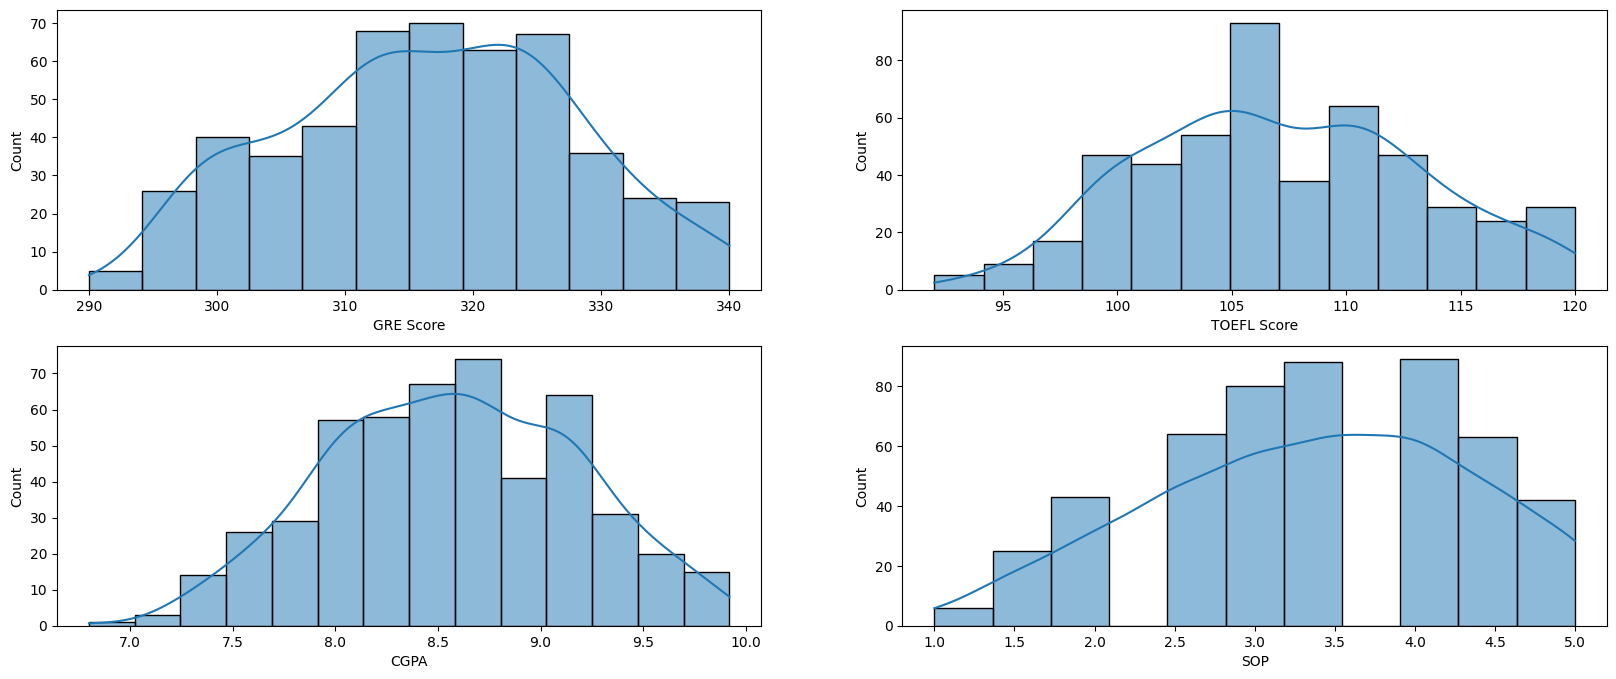

In [10]:
fig,axes=plt.subplots(nrows=3,ncols=2,figsize=(20,8))
plt.subplot(2,2,1)
sns.histplot(df1['GRE Score'],kde='True')
plt.subplot(2,2,2)
sns.histplot(df1['TOEFL Score'],kde='True')
plt.subplot(2,2,3)
sns.histplot(df1['CGPA'],kde='True')
plt.subplot(2,2,4)
sns.histplot(df1['SOP'],kde='True')




Text(0, 0.5, 'University Rating')

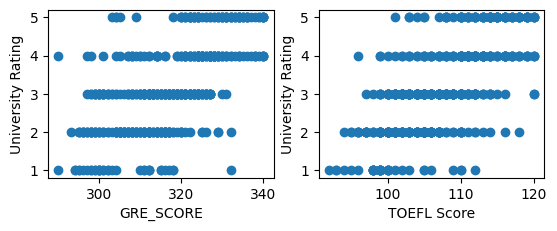

In [11]:
plt.subplot(2,2,1)
plt.scatter(df1['GRE Score'],df1['University Rating'])
plt.xlabel('GRE_SCORE')
plt.ylabel('University Rating')
plt.subplot(2,2,2)
plt.scatter(df1['TOEFL Score'],df1['University Rating'])
plt.xlabel('TOEFL Score')
plt.ylabel('University Rating')


<Axes: xlabel='SOP'>

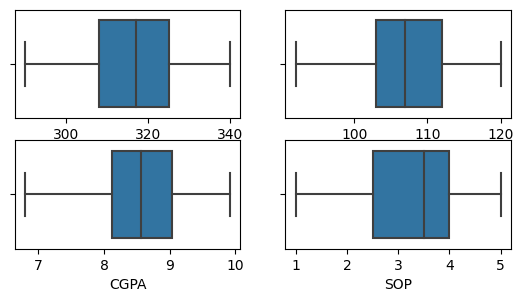

In [12]:
plt.subplot(3,2,1)
sns.boxplot(data=df1,x='GRE Score')
plt.subplot(3,2,2)
sns.boxplot(data=df1,x='TOEFL Score')
plt.subplot(3,2,3)
sns.boxplot(data=df1,x='CGPA')
plt.subplot(3,2,4)
sns.boxplot(data=df1,x='SOP')


We do not have any potential Outliers 

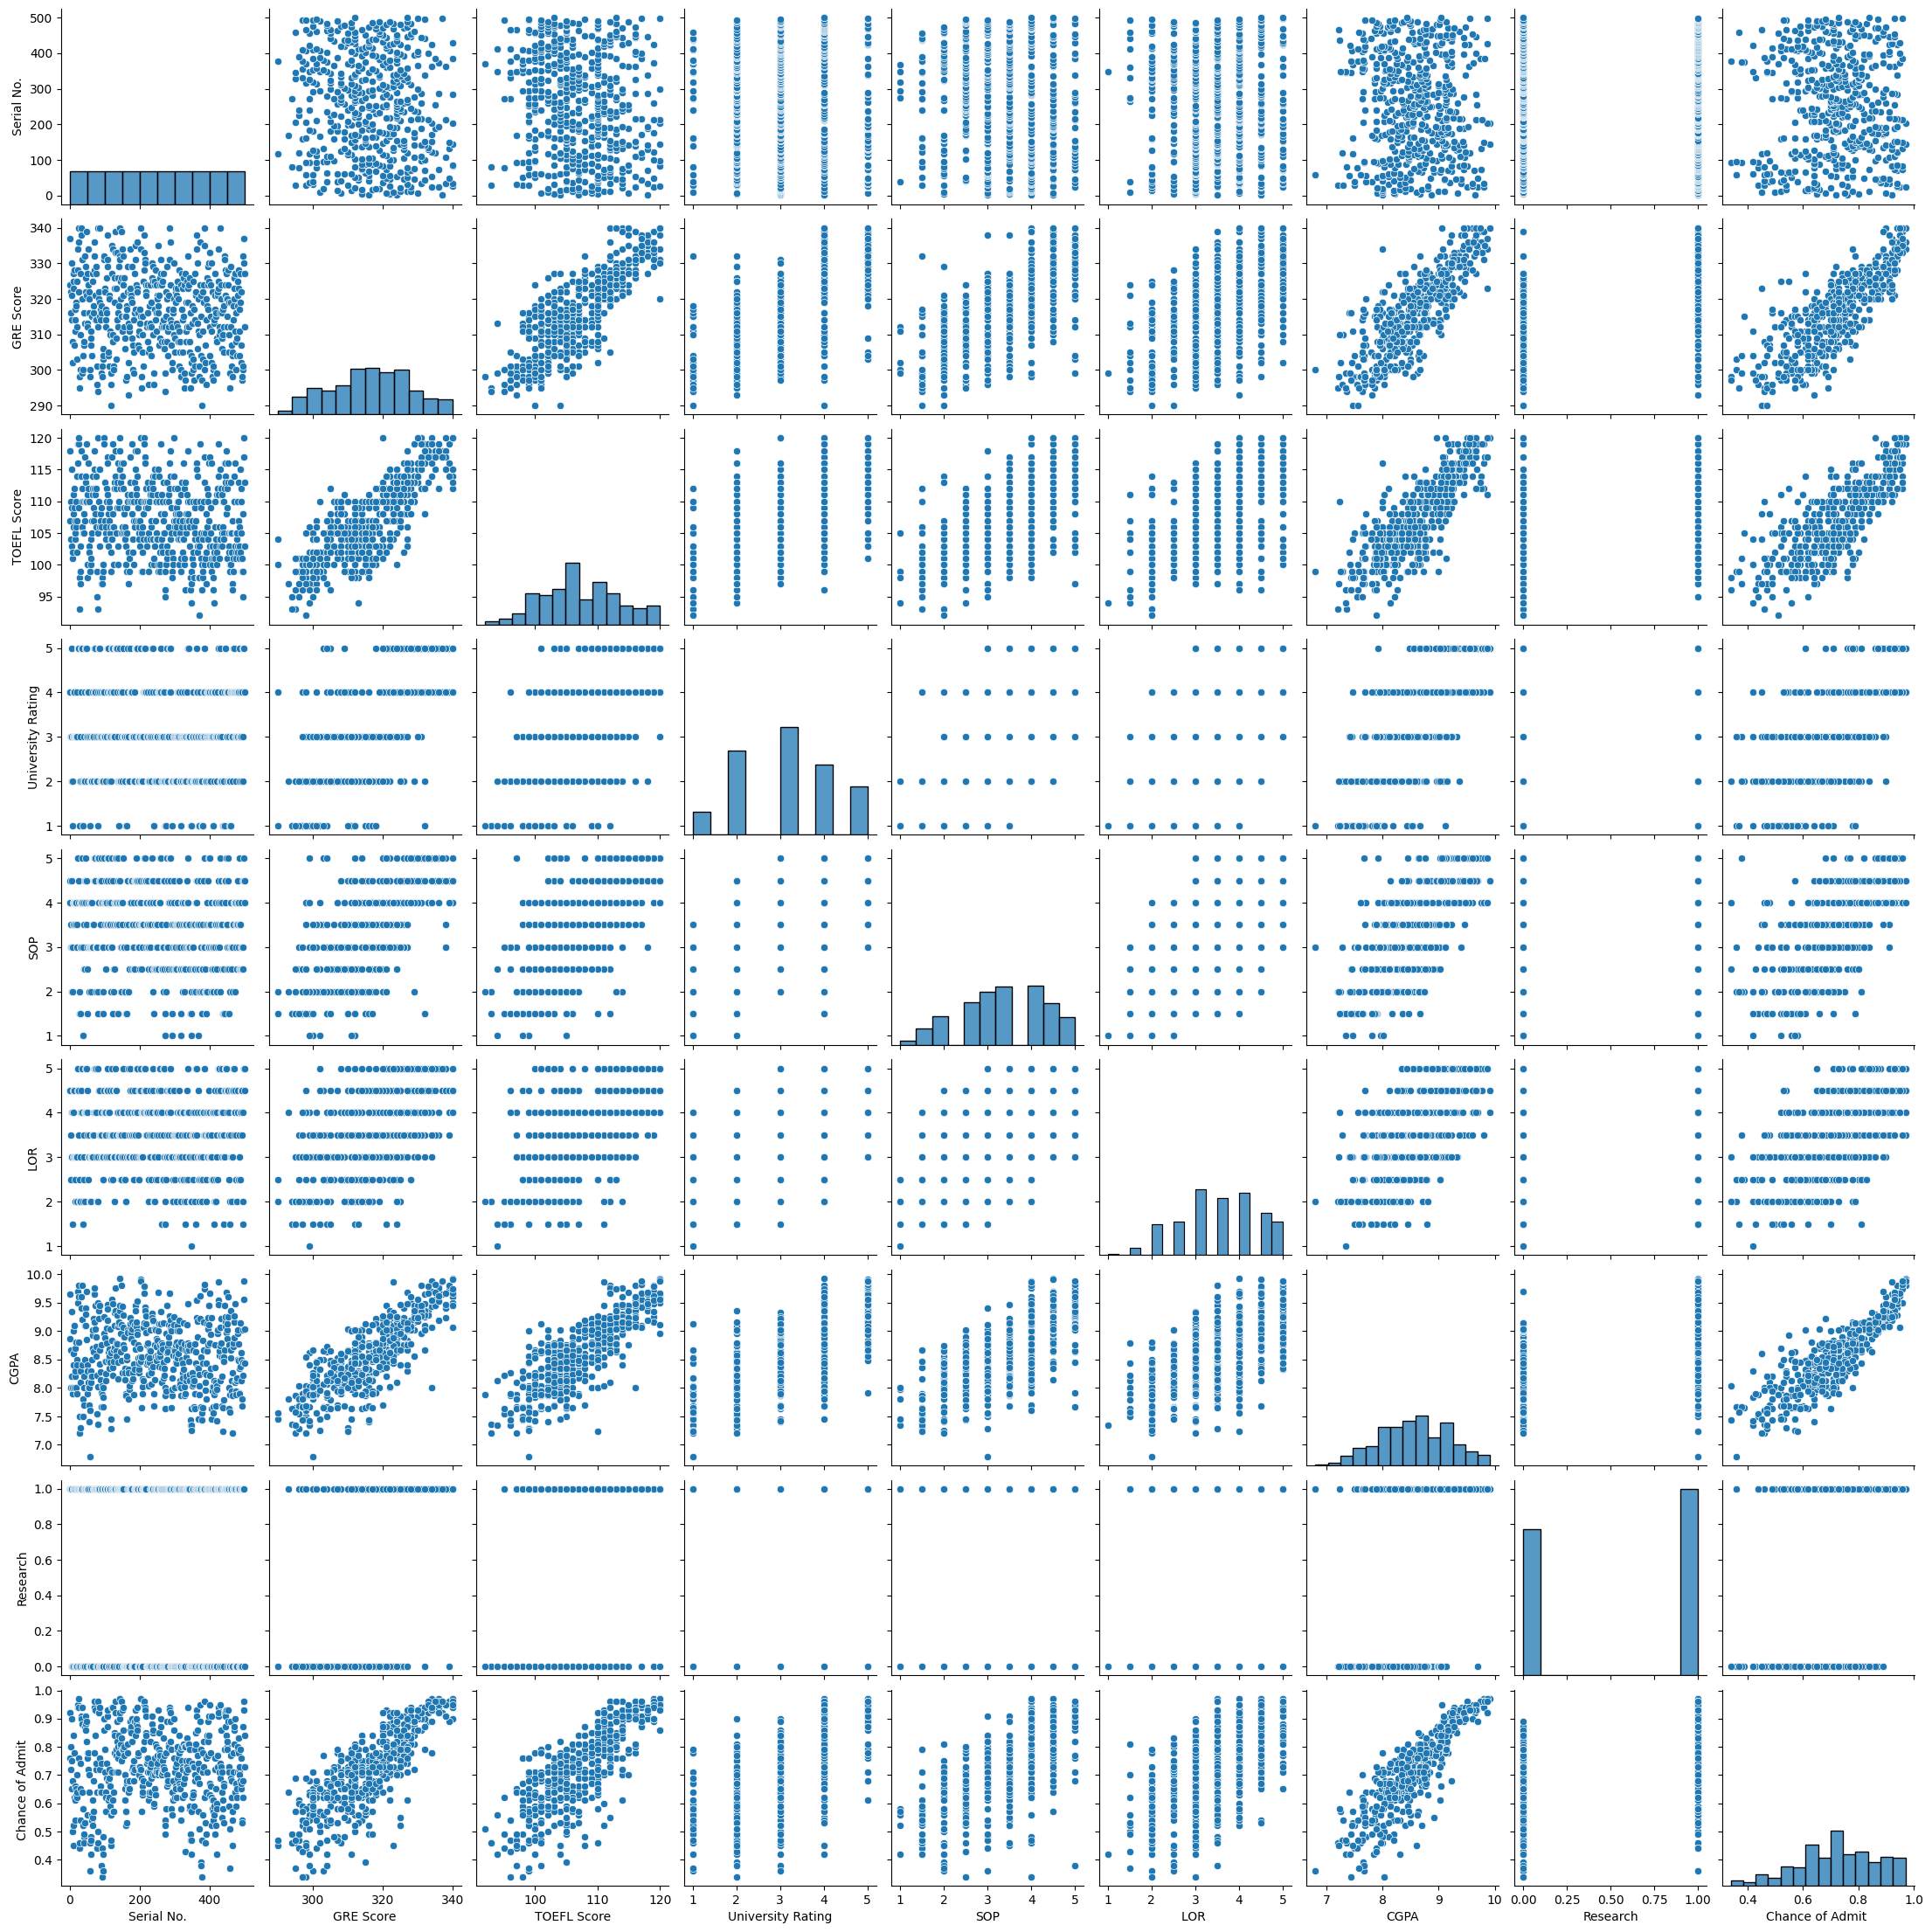

In [13]:
sns.pairplot(df1)

Data Preprocessing

<Axes: >

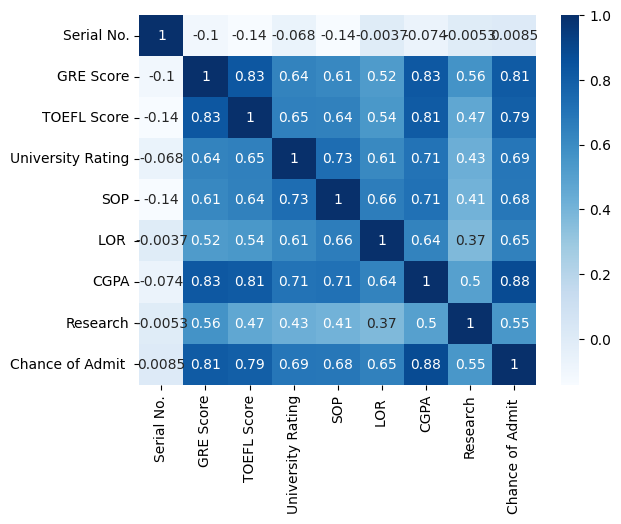

In [14]:
sns.heatmap(df1.corr(),annot=True,cmap='Blues')

We dont have any correlated feature with >0.90

Data Preprocessing for Modelling


In [15]:
le=LabelEncoder()
cols=['University Rating', 'SOP', 'LOR ', 'Research']
for i in cols:
    df1[i]=le.fit_transform(df1[i])
    


In [16]:
df_model1=df1.drop(columns='Serial No.')
df_model1

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,3,7,7,9.65,1,0.92
1,324,107,3,6,7,8.87,1,0.76
2,316,104,2,4,5,8.00,1,0.72
3,322,110,2,5,3,8.67,1,0.80
4,314,103,1,2,4,8.21,0,0.65
...,...,...,...,...,...,...,...,...
495,332,108,4,7,6,9.02,1,0.87
496,337,117,4,8,8,9.87,1,0.96
497,330,120,4,7,8,9.56,1,0.93
498,312,103,3,6,8,8.43,0,0.73


In [23]:
le = LabelEncoder()
df_model1['University Rating']=le.fit_transform(df_model1['University Rating'])
df_model1['SOP']=le.fit_transform(df_model1['SOP'])
df_model1

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,3,7,7,9.65,1,0.92
1,324,107,3,6,7,8.87,1,0.76
2,316,104,2,4,5,8.00,1,0.72
3,322,110,2,5,3,8.67,1,0.80
4,314,103,1,2,4,8.21,0,0.65
...,...,...,...,...,...,...,...,...
495,332,108,4,7,6,9.02,1,0.87
496,337,117,4,8,8,9.87,1,0.96
497,330,120,4,7,8,9.56,1,0.93
498,312,103,3,6,8,8.43,0,0.73


In [25]:
minmax_trans=MinMaxScaler()
minmax_trans.fit(df_model1)
scalerd_feature=minmax_trans.transform(df_model1)
df2=pd.DataFrame(data=scalerd_feature, columns=['University Rating', 'SOP', 'LOR', 'Research', 'GRE Score',
       'TOEFL Score', 'CGPA', 'Chance of Admit'])
df2


,University Rating,SOP,LOR,Research,GRE Score,TOEFL Score,CGPA,Chance of Admit
0,0.94,0.928571,0.75,0.875,0.875,0.913462,1.0,0.920635
1,0.68,0.535714,0.75,0.750,0.875,0.663462,1.0,0.666667
2,0.52,0.428571,0.50,0.500,0.625,0.384615,1.0,0.603175
3,0.64,0.642857,0.50,0.625,0.375,0.599359,1.0,0.730159
4,0.48,0.392857,0.25,0.250,0.500,0.451923,0.0,0.492063
...,...,...,...,...,...,...,...,...
495,0.84,0.571429,1.00,0.875,0.750,0.711538,1.0,0.841270
496,0.94,0.892857,1.00,1.000,1.000,0.983974,1.0,0.984127
497,0.80,1.000000,1.00,0.875,1.000,0.884615,1.0,0.936508
498,0.44,0.392857,0.75,0.750,1.000,0.522436,0.0,0.619048


In [26]:
X = df2[['University Rating', 'SOP', 'LOR', 'Research', 'GRE Score','TOEFL Score', 'CGPA']]
Y = df2['Chance of Admit']
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [27]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
model.score(x_test,y_test)

0.8014876838850891

In [28]:
x_train = x_train.drop(labels=['SOP'], axis=1)
x_test = x_test.drop(labels=['SOP'], axis=1)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
model.score(x_test, y_test)

0.7937187520713511

In [29]:
scaler=StandardScaler()
x_trained_scaler=scaler.fit_transform(x_train)
x_sm=sm.add_constant(x_train)
model=sm.OLS(y_train,x_sm)
result=model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     307.6
Date:                Sat, 12 Oct 2024   Prob (F-statistic):          4.58e-145
Time:                        14:13:40   Log-Likelihood:                 383.42
No. Observations:                 400   AIC:                            -752.8
Df Residuals:                     393   BIC:                            -724.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0176      0.01

In [33]:
x_sm

,const,University Rating,LOR,Research,GRE Score,TOEFL Score,CGPA
338,1.0,0.66,1.00,0.750,0.750,0.621795,1.0
481,1.0,0.66,0.75,0.500,0.375,0.538462,1.0
309,1.0,0.36,0.75,0.625,0.500,0.576923,0.0
29,1.0,0.40,0.25,0.125,0.250,0.160256,0.0
149,1.0,0.42,0.25,0.625,0.500,0.467949,1.0
...,...,...,...,...,...,...,...
485,1.0,0.42,0.25,0.375,0.625,0.493590,1.0
205,1.0,0.10,0.25,0.375,0.500,0.272436,0.0
386,1.0,0.24,0.25,0.375,0.625,0.371795,0.0
17,1.0,0.58,0.50,0.750,0.500,0.384615,1.0


VIF

In [41]:
from statsmodels.stats.outliers_influence import  variance_inflation_factor

vif=pd.DataFrame()
vif['Features']=x_sm.columns
vif['VIF']=[variance_inflation_factor(x_sm,i) for i in range(x_sm.shape[1])]
vif.sort_values(by='VIF',ascending=False)
vif

,Features,VIF
0,const,11.747323
1,University Rating,3.792738
2,LOR,2.574185
3,Research,2.882296
4,GRE Score,2.034780
5,TOEFL Score,4.841809
6,CGPA,1.456791


Normality of Residuals

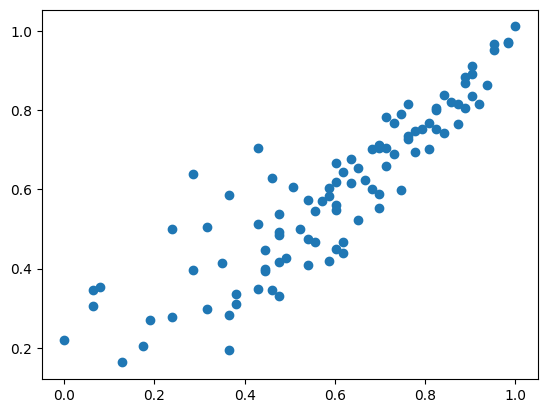

In [43]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)
plt.scatter(y_test,y_pred)

Text(0.5, 1.0, 'Histogram of Residuals')

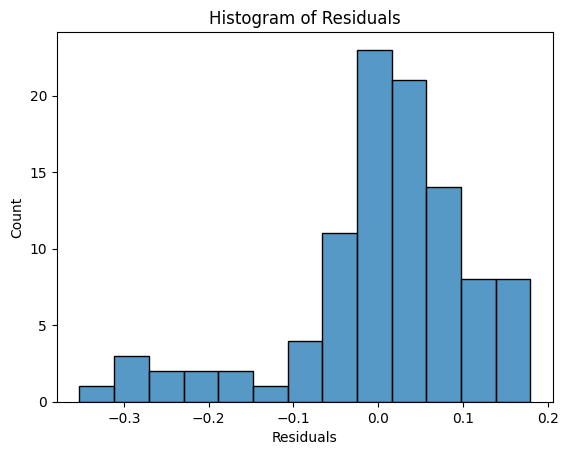

In [46]:
errors=y_test-y_pred
sns.histplot(errors)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")

<Axes: ylabel='Chance of Admit'>

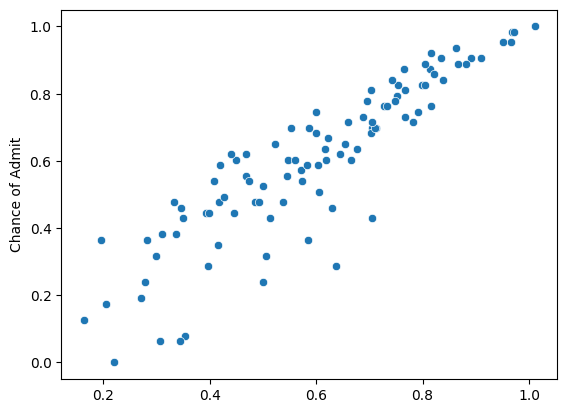

In [47]:
sns.scatterplot(x=y_pred,y=y_test)

In [54]:
df3 = df2[['University Rating', 'LOR', 'Research', 'GRE Score','TOEFL Score', 'CGPA']]

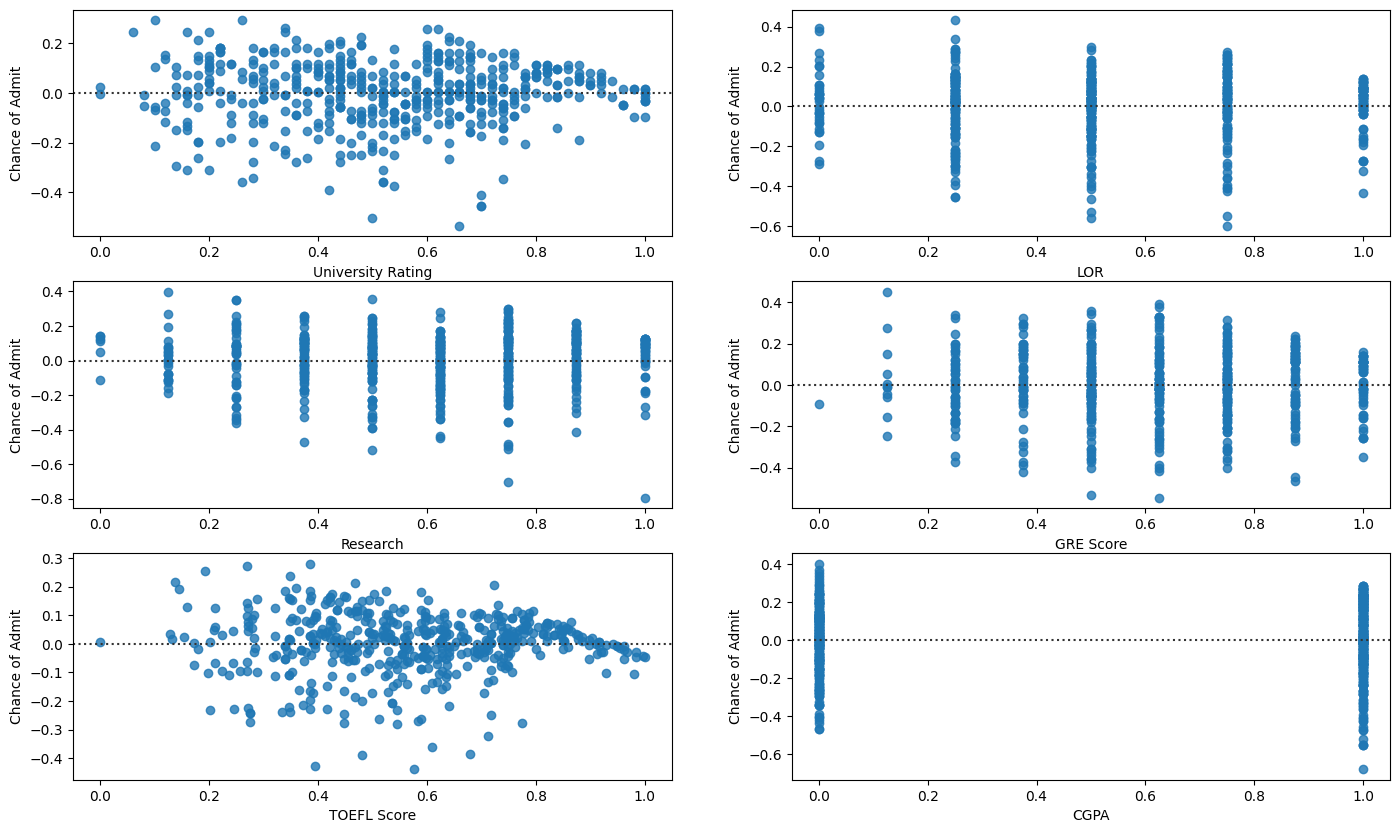

In [56]:
count = 1
plt.figure(figsize=(17,10))
for i in df3.columns:
  plt.subplot(3,2,count)
  sns.residplot(x = df3[i], y= df2['Chance of Admit'])
  count += 1